In [174]:
sites = ["GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA", "ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC", "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC", "CAGGTTGGC"]

### Задание 3.

In [177]:
import Bio as bp
from Bio import motifs
from Bio.Seq import Seq
from Bio import SeqIO
import random
import matplotlib.pyplot as plt
import numpy as np

In [179]:
sequences = [Seq(site) for site in sites]
motif = motifs.create(sequences)
ppm = motif.counts.normalize(pseudocounts=0.1)
pssm = ppm.log_odds(background={'A':0.295, 'T':0.295, 'G':0.205, 'C':0.205})

In [181]:
pssm

{'A': [-1.4797949590909114,
  1.400623425156416,
  -1.4797949590909116,
  -4.939226577728209,
  -4.939226577728209,
  -0.5469091549494484,
  1.210520541776473,
  -0.5469091549494486,
  -1.4797949590909114],
 'C': [1.516601804578435,
  -0.021818110205690678,
  -0.954703914347154,
  -4.414135532984451,
  -4.414135532984451,
  1.516601804578435,
  -4.414135532984451,
  -4.414135532984451,
  1.9257144699001736],
 'G': [-0.9547039143471536,
  -4.414135532984451,
  1.9257144699001734,
  2.2440759497673435,
  -4.414135532984451,
  -4.414135532984451,
  0.5400607774024242,
  1.9257144699001734,
  -4.414135532984451],
 'T': [-0.5469091549494484,
  -4.939226577728209,
  -4.939226577728209,
  -4.939226577728209,
  1.7189849050235857,
  -0.5469091549494484,
  -4.939226577728209,
  -4.939226577728209,
  -1.4797949590909114]}

In [183]:
def random_nucl_generator(L, background={'A':0.295, 'T':0.295, 'G':0.205, 'C':0.205}):
    bases = list(background.keys())
    ps = list(background.values())
    
    sequence = random.choices(bases, weights=ps, k=L)
    return ''.join(sequence)

In [185]:
random_nucl_generator(9)

'GTTTAAGTC'

In [187]:
n_seqs = 100000
all_seqs = []
for _ in range(n_seqs):
    all_seqs.append(random_nucl_generator(9))

all_seqs[:5]

['TATGCAATT', 'TCTTTCGAT', 'ACTACTGCA', 'CCATTGGTT', 'GAGAGAGCA']

In [189]:
scores = []
for seq in all_seqs:
    score = pssm.calculate(seq)
    scores.append(score)

scores[:5]

[-12.0109825, -8.698237, -21.69498, -13.498349, -12.882507]

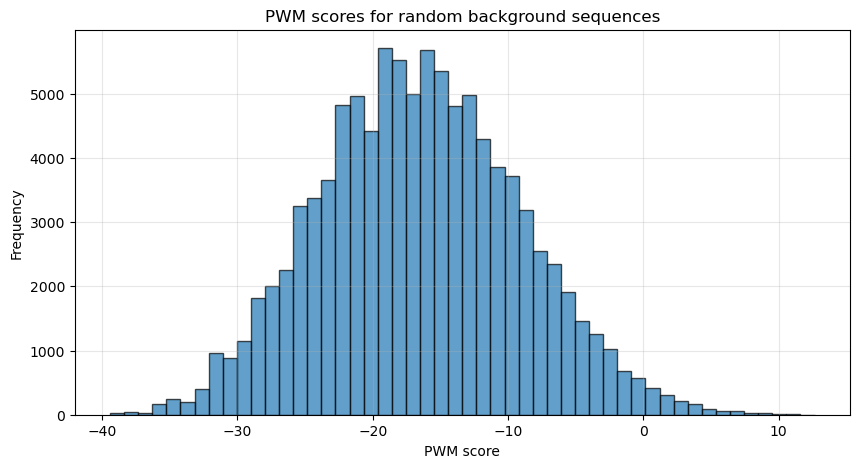

In [190]:
plt.figure(figsize=(10,5))
plt.hist(scores, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('PWM score')
plt.ylabel('Frequency')
plt.title('PWM scores for random background sequences')
plt.grid(True, alpha=0.3)
plt.show()

In [191]:
def get_pvalue(score, scores):
    scores = np.array(scores)
    count_greater = np.sum(scores >= score)
    return count_greater / len(scores)

In [193]:
for t in [0, 5, 10, 10.5]:
    print(f"Для порога {t} — p-value={get_pvalue(t, scores)}")

Для порога 0 — p-value=0.01476
Для порога 5 — p-value=0.00213
Для порога 10 — p-value=0.00012
Для порога 10.5 — p-value=9e-05
